In [1]:
# Step 1: Import gymnasium and create LunarLander environment
import gymnasium as gym
import matplotlib.pyplot as plt
from itertools import product
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import pandas as pd
import time  #-------

# Import DDPG from stable-baselines3
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.logger import configure  # -------

2025-05-04 01:58:13.904663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-04 01:58:13.919739: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-04 01:58:13.924124: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-04 01:58:13.936350: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Create reward/loss trackers
reward_tracking = {}
loss_tracking = {}
training_times = {}  #-------

In [3]:
# Define callback to track rewards/losses
class RewardLossLogger(BaseCallback):
    def __init__(self, model_name, verbose=0):
        super().__init__(verbose)
        self.model_name = model_name
        self.rewards = []
        self.losses = []

    def _on_step(self) -> bool:
        if self.locals.get("dones") is not None and any(self.locals["dones"]):
            self.rewards.append(sum(self.locals["rewards"]))
        return True

    def _on_training_end(self) -> None:
        reward_tracking[self.model_name] = self.rewards
        # No direct loss access in DDPG so we skip that

In [11]:
from IPython.display import Markdown, display  #-------

def show_testing_matrix():  #-------
    matrix_md = """
### Parameters Testing Matrix

| Category              | Options                             | Count |
|-----------------------|-------------------------------------|--------|
| **Architectures**     | `[64, 64]`, `[128,128,128]`          | 2      |
| **Activations**       | `ReLU`, `Tanh`                      | 2      |
| **Optimizers**        | `Adam`, `SGD`                       | 2      |
| **Exploration Sigmas** |[0.1, 0.3] | 2 |
| **Replay Settings**   | 2 dicts {"buffer_size", "train_freq", "learning_starts"} | 2 |

**Total combinations:** `2 x 2 x 2 x 2 x 2 = 32 models`
"""
    display(Markdown(matrix_md))  #-------

show_testing_matrix()  #-------


### Parameters Testing Matrix

| Category              | Options                             | Count |
|-----------------------|-------------------------------------|--------|
| **Architectures**     | `[64, 64]`, `[128,128,128]`          | 2      |
| **Activations**       | `ReLU`, `Tanh`                      | 2      |
| **Optimizers**        | `Adam`, `SGD`                       | 2      |
| **Exploration Sigmas** |[0.1, 0.3] | 2 |
| **Replay Settings**   | 2 dicts {"buffer_size", "train_freq", "learning_starts"} | 2 |

**Total combinations:** `2 x 2 x 2 x 2 x 2 = 32 models`


In [4]:
# Define experimental grids
architectures = [[64, 64], [128, 128, 128]]
activations = {"relu": nn.ReLU, "tanh": nn.Tanh}
optimizers = {"adam": optim.Adam, "sgd": optim.SGD}
exploration_sigmas = [0.1, 0.3]
replay_settings = [
    {"buffer_size": 1000000, "train_freq": (1, "episode"), "learning_starts": 1000},
    {"buffer_size": 500000, "train_freq": (1, "step"), "learning_starts": 500}
]

configs = list(product(architectures, activations.items(), optimizers.items(), exploration_sigmas, replay_settings))
results = []

In [5]:
for arch, (act_name, act_fn), (opt_name, opt_cls), sigma, replay_cfg in configs:
    model_name = f"{len(arch)}x{arch[0]}_{act_name}_{opt_name}_sigma{sigma}_start{replay_cfg['learning_starts']}"

    policy_kwargs = dict(
        net_arch=arch,
        activation_fn=act_fn,
        optimizer_class=opt_cls
    )

    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    log_dir = f"./ddpg_logs/{model_name}/"
    os.makedirs(log_dir, exist_ok=True)
    env = Monitor(env, filename=log_dir + "monitor.csv")

    n_actions = env.action_space.shape[0]
    action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=sigma * np.ones(n_actions))

    model = DDPG(
        "MlpPolicy",
        env,
        policy_kwargs=policy_kwargs,
        buffer_size=replay_cfg['buffer_size'],
        train_freq=replay_cfg['train_freq'],
        learning_starts=replay_cfg['learning_starts'],
        action_noise=action_noise,
        verbose=0
    )

    # Add TensorBoard logging
    new_logger = configure(log_dir, ["tensorboard"])
    model.set_logger(new_logger)

    callback = RewardLossLogger(model_name)
    start_time = time.time()  #-------
    model.learn(total_timesteps=50000, callback=callback, progress_bar=False)
    train_time = time.time() - start_time  #-------
    training_times[model_name] = train_time  #-------

    model.save(f"ddpg_{model_name}")

    mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=5, render=False)

    print(f"✅ Trained: {model_name} | Reward: {mean_reward:.2f} | Time: {train_time:.2f} sec")  #-------

    
    results.append({
        "name": model_name,
        "arch": arch,
        "activation": act_name,
        "optimizer": opt_name,
        "sigma": sigma,
        "replay": replay_cfg,
        "mean_reward": mean_reward,
        "std_reward": std_reward, 
        "time": train_time  #-------
    })

    env.close()

✅ Trained: 2x64_relu_adam_sigma0.1_start1000 | Reward: -83.09 | Time: 55.15 sec
✅ Trained: 2x64_relu_adam_sigma0.1_start500 | Reward: -5.24 | Time: 410.17 sec
✅ Trained: 2x64_relu_adam_sigma0.3_start1000 | Reward: -370.27 | Time: 57.22 sec
✅ Trained: 2x64_relu_adam_sigma0.3_start500 | Reward: 11.92 | Time: 420.59 sec
✅ Trained: 2x64_relu_sgd_sigma0.1_start1000 | Reward: -309.57 | Time: 51.89 sec
✅ Trained: 2x64_relu_sgd_sigma0.1_start500 | Reward: -13.64 | Time: 379.53 sec
✅ Trained: 2x64_relu_sgd_sigma0.3_start1000 | Reward: -198.93 | Time: 52.14 sec
✅ Trained: 2x64_relu_sgd_sigma0.3_start500 | Reward: -160.20 | Time: 326.03 sec
✅ Trained: 2x64_tanh_adam_sigma0.1_start1000 | Reward: -585.45 | Time: 36.94 sec
✅ Trained: 2x64_tanh_adam_sigma0.1_start500 | Reward: -58.64 | Time: 331.07 sec
✅ Trained: 2x64_tanh_adam_sigma0.3_start1000 | Reward: -156.51 | Time: 35.07 sec
✅ Trained: 2x64_tanh_adam_sigma0.3_start500 | Reward: -38.45 | Time: 300.76 sec
✅ Trained: 2x64_tanh_sgd_sigma0.1_start1

In [6]:
# Convert to DataFrame and show results
results_df = pd.DataFrame(results)
print(results_df.sort_values("mean_reward", ascending=False))


                                  name             arch activation optimizer  \
31    3x128_tanh_sgd_sigma0.3_start500  [128, 128, 128]       tanh       sgd   
27   3x128_tanh_adam_sigma0.3_start500  [128, 128, 128]       tanh      adam   
3     2x64_relu_adam_sigma0.3_start500         [64, 64]       relu      adam   
1     2x64_relu_adam_sigma0.1_start500         [64, 64]       relu      adam   
5      2x64_relu_sgd_sigma0.1_start500         [64, 64]       relu       sgd   
23    3x128_relu_sgd_sigma0.3_start500  [128, 128, 128]       relu       sgd   
11    2x64_tanh_adam_sigma0.3_start500         [64, 64]       tanh      adam   
15     2x64_tanh_sgd_sigma0.3_start500         [64, 64]       tanh       sgd   
9     2x64_tanh_adam_sigma0.1_start500         [64, 64]       tanh      adam   
0    2x64_relu_adam_sigma0.1_start1000         [64, 64]       relu      adam   
25   3x128_tanh_adam_sigma0.1_start500  [128, 128, 128]       tanh      adam   
21    3x128_relu_sgd_sigma0.1_start500  

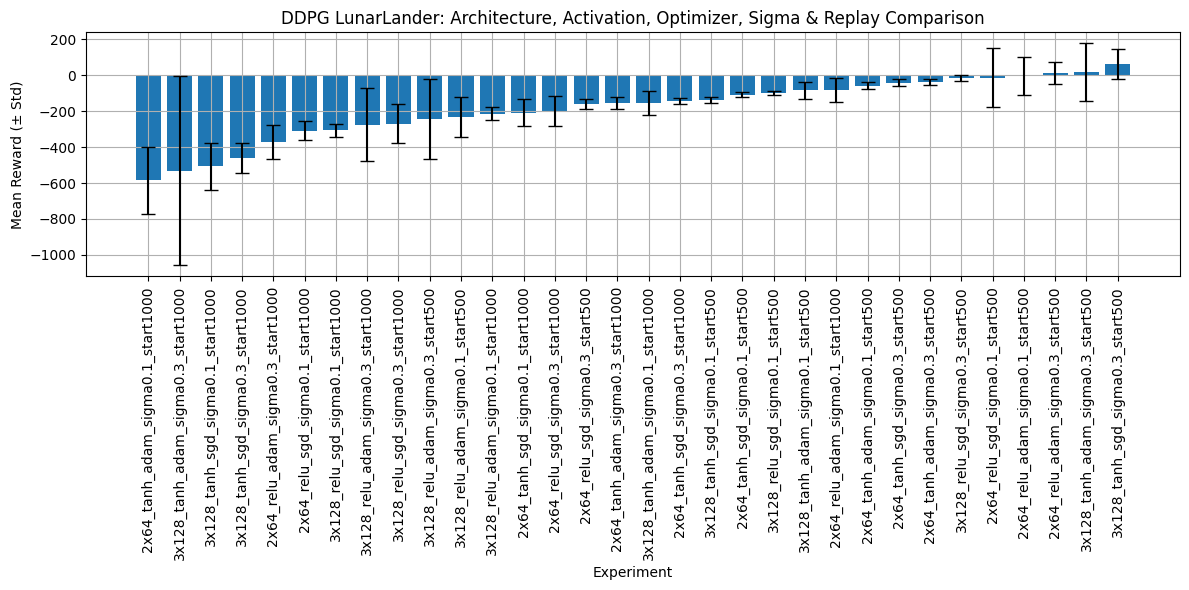

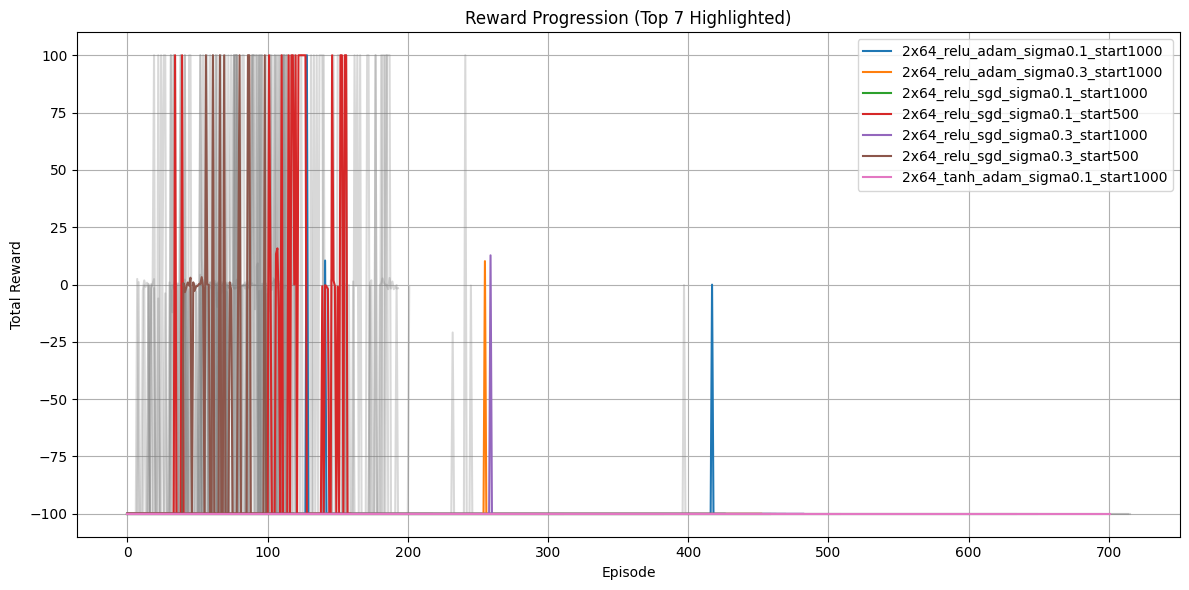

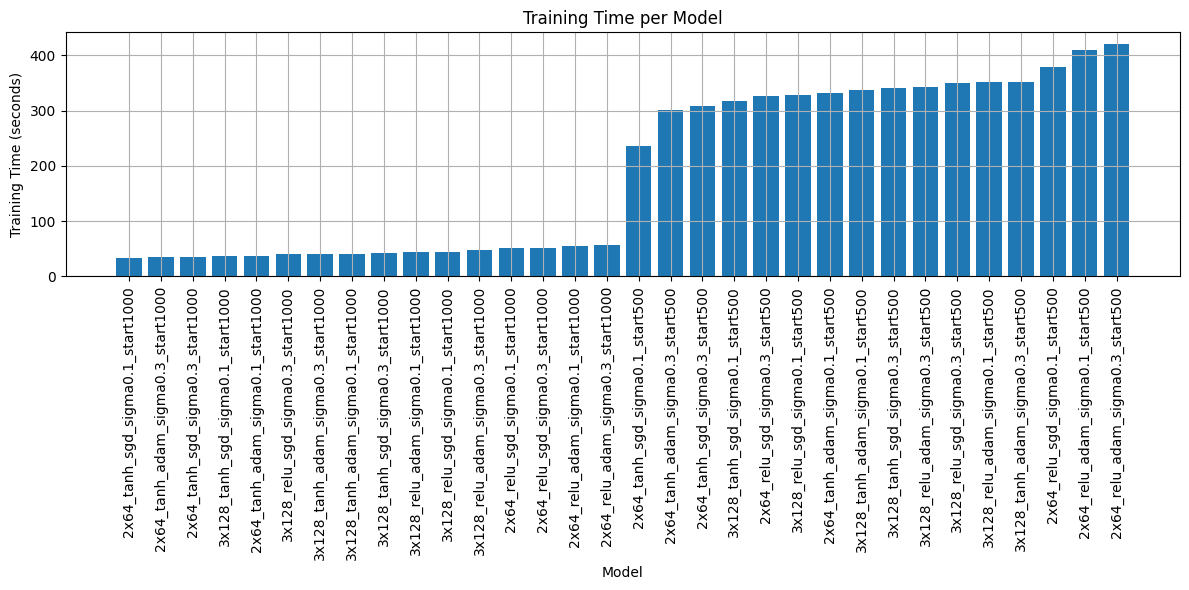

In [9]:

# Plot comparison of mean rewards in ascending order
sorted_results_df = results_df.sort_values(by="mean_reward", ascending=True)
plt.figure(figsize=(12, 6))
plt.bar(sorted_results_df['name'], sorted_results_df['mean_reward'], yerr=sorted_results_df['std_reward'], capsize=5)
plt.title("DDPG LunarLander: Architecture, Activation, Optimizer, Sigma & Replay Comparison")
plt.xlabel("Experiment")
plt.ylabel("Mean Reward (± Std)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

# Highlight Top 7 reward progressions
sorted_keys = sorted(reward_tracking.keys(), key=lambda k: reward_tracking[k][-1] if reward_tracking[k] else float('-inf'))
highlight = sorted_keys[:7]
faint = sorted_keys[7:]

plt.figure(figsize=(12, 6))
for name in faint:
    plt.plot(reward_tracking[name], color='gray', alpha=0.3)
for name in highlight:
    plt.plot(reward_tracking[name], label=name)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Progression (Top 7 Highlighted)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot training time per model (sorted)
sorted_speed_items = sorted(training_times.items(), key=lambda item: item[1])
sorted_speed_keys = [item[0] for item in sorted_speed_items]
sorted_speed_values = [item[1] for item in sorted_speed_items]

plt.figure(figsize=(12, 6))
plt.bar(sorted_speed_keys, sorted_speed_values)
plt.title("Training Time per Model")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()



/tmp/ipykernel_487898/1889689287.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="name", y="mean_reward", data=results_df, errorbar=None, palette="viridis")


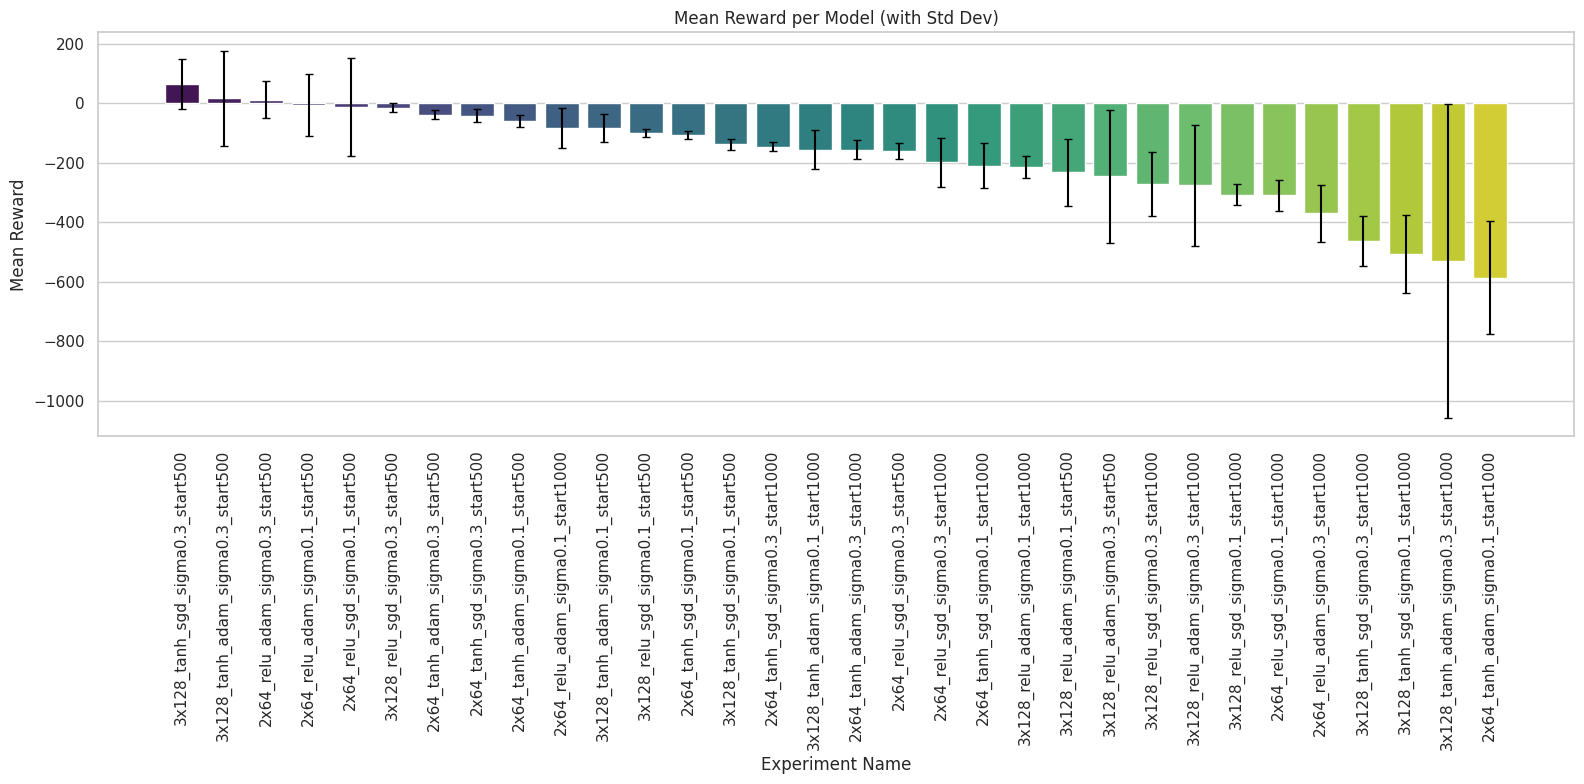

/tmp/ipykernel_487898/1889689287.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="activation", y="mean_reward", data=results_df, palette="pastel")


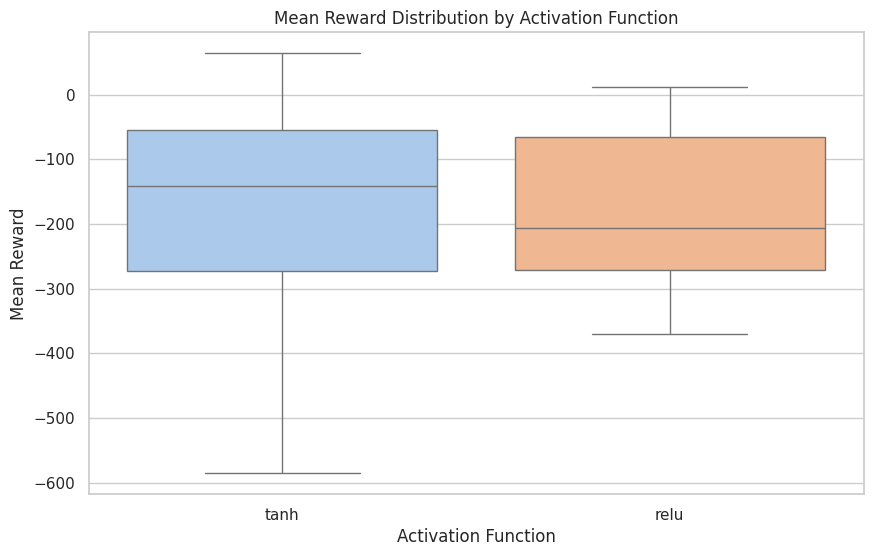

/tmp/ipykernel_487898/1889689287.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="optimizer", y="mean_reward", data=results_df, palette="coolwarm")


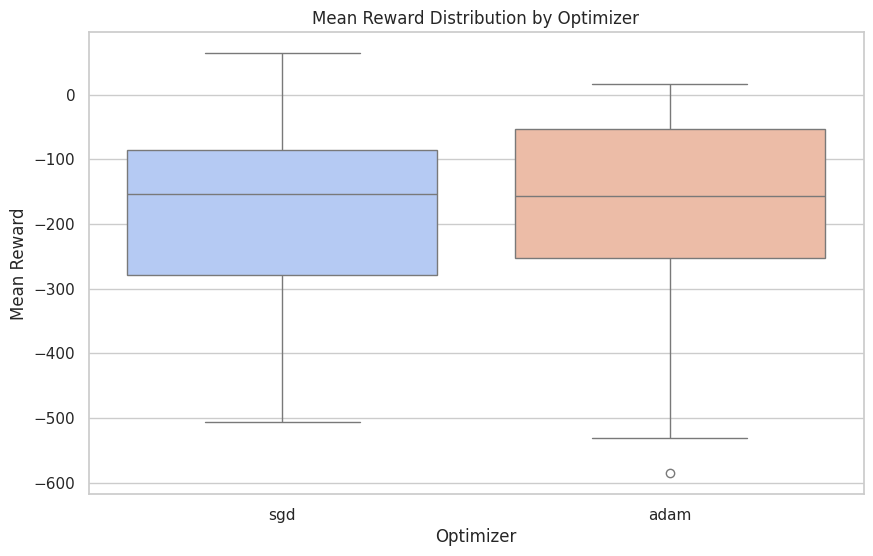

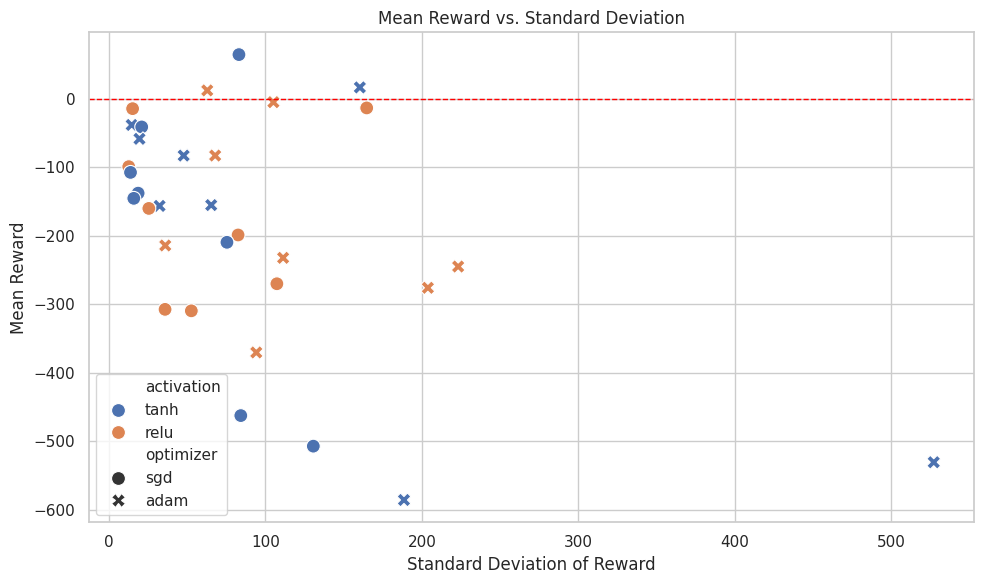

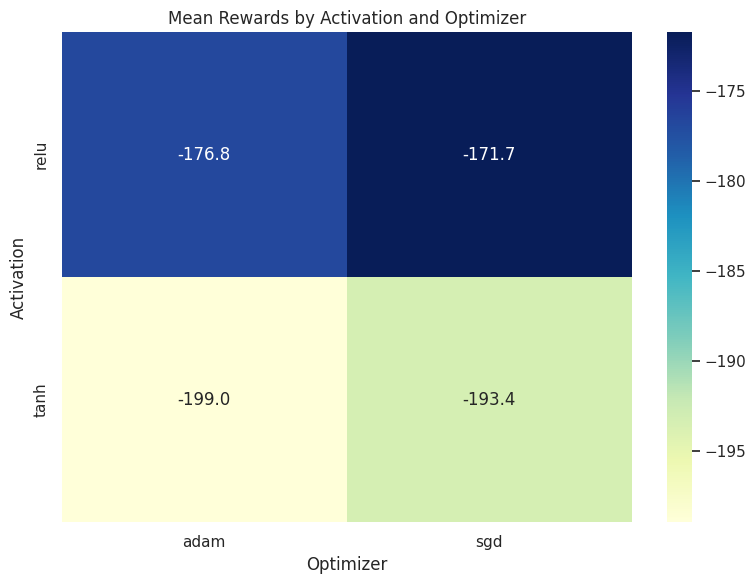

/tmp/ipykernel_487898/1889689287.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="sigma", y="mean_reward", data=results_df, palette="Set2")


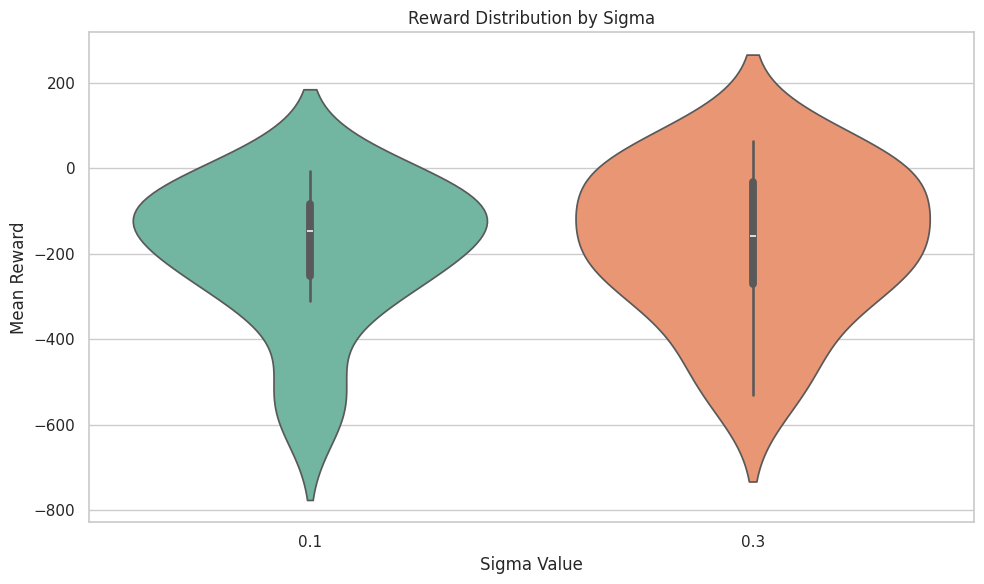

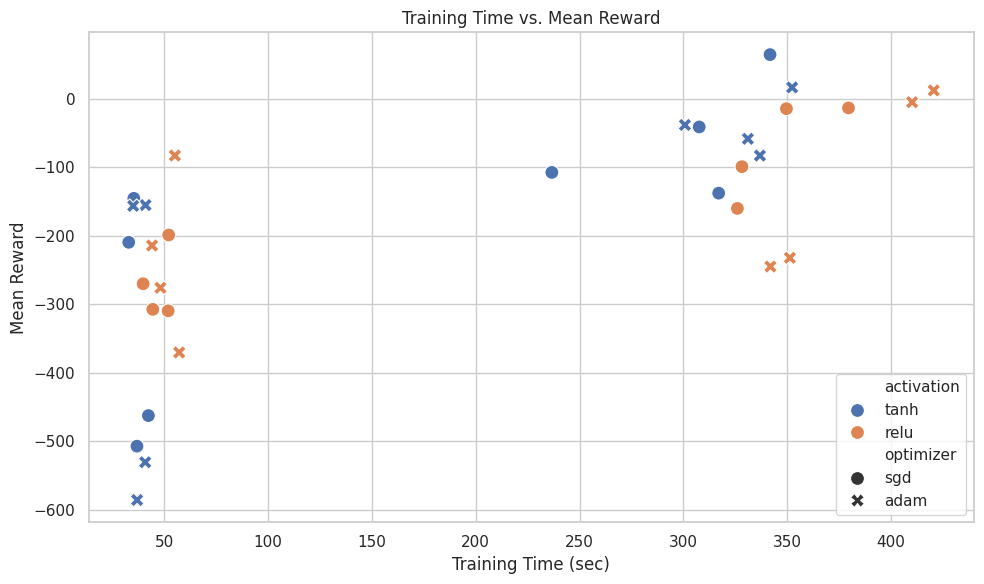

In [13]:
import seaborn as sns

# Set seaborn theme for better aesthetics
sns.set(style="whitegrid")

# Convert to DataFrame if not already
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)

# ---------- 1. Bar plot of mean reward per experiment ----------
plt.figure(figsize=(16, 8))
sns.barplot(x="name", y="mean_reward", data=results_df, errorbar=None, palette="viridis")
plt.errorbar(x=range(len(results_df)), y=results_df["mean_reward"], 
             yerr=results_df["std_reward"], fmt='none', c='black', capsize=3)
plt.title("Mean Reward per Model (with Std Dev)")
plt.xlabel("Experiment Name")
plt.ylabel("Mean Reward")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ---------- 2. Boxplot grouped by Activation Function ----------
plt.figure(figsize=(10, 6))
sns.boxplot(x="activation", y="mean_reward", data=results_df, palette="pastel")
plt.title("Mean Reward Distribution by Activation Function")
plt.xlabel("Activation Function")
plt.ylabel("Mean Reward")
plt.show()

# ---------- 3. Boxplot grouped by Optimizer ----------
plt.figure(figsize=(10, 6))
sns.boxplot(x="optimizer", y="mean_reward", data=results_df, palette="coolwarm")
plt.title("Mean Reward Distribution by Optimizer")
plt.xlabel("Optimizer")
plt.ylabel("Mean Reward")
plt.show()

# ---------- 4. Scatter plot: Mean Reward vs. Std Dev ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="std_reward", y="mean_reward", hue="activation", style="optimizer", s=100)
plt.title("Mean Reward vs. Standard Deviation")
plt.xlabel("Standard Deviation of Reward")
plt.ylabel("Mean Reward")
plt.axhline(0, color='red', linestyle='--', lw=1)
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- 5. Heatmap of Mean Rewards by Activation and Optimizer ----------
pivot_table = results_df.pivot_table(values="mean_reward", index="activation", columns="optimizer", aggfunc="mean")
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Mean Rewards by Activation and Optimizer")
plt.xlabel("Optimizer")
plt.ylabel("Activation")
plt.tight_layout()
plt.show()

# ---------- 6. Violin plot of reward distribution grouped by sigma ----------
plt.figure(figsize=(10, 6))
sns.violinplot(x="sigma", y="mean_reward", data=results_df, palette="Set2")
plt.title("Reward Distribution by Sigma")
plt.xlabel("Sigma Value")
plt.ylabel("Mean Reward")
plt.tight_layout()
plt.show()

# ---------- 7. Training Time vs. Mean Reward ----------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="time", y="mean_reward", hue="activation", style="optimizer", s=100)
plt.title("Training Time vs. Mean Reward")
plt.xlabel("Training Time (sec)")
plt.ylabel("Mean Reward")
plt.grid(True)
plt.tight_layout()
plt.show()
